# Power-law tail extrapolation for buffer-stock consumption functions

Buffer-stock consumption theory proves two laws about the consumption function
$c(m)$ (normalized market resources $m$) **beyond any finite solution grid** —
one at the high-wealth (**top**) end and one at the borrowing-constraint
(**bottom**) end. `IndShockConsumerType` can attach both as opt-in, theorem-pinned
tail extrapolators (`decay_extrap_form='powerlaw'` on top,
`decay_extrap_form_lower='kappabar'` on the bottom); the defaults `None` leave
behavior byte-for-byte unchanged.

This notebook reproduces, **inside HARK**, the spirit of the theory program's
[extrapolators-in-practice](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/extrapolators-in-practice)
experiment: a small grid *finished with these tails* reproduces a vastly larger
grid's solution, and the tails matter **inside the solver** (the Euler
expectations), not only on the returned policy.

**Reading guide.** The headline results are honest and specific:

* **Top:** the power-law tail is the *asymptotically correct* decay shape, but
  HARK's existing default top extrapolation is already an exp-decay toward the
  same perfect-foresight (PF) line, so at a sensible grid top the two are numerically
  close. Both beat the *naive PF line* (no decay) by ~an order of magnitude, and the
  power-law tail is meaningfully better than exp only when the grid top is
  **pre-asymptotic** (the failure case below).
* **Bottom:** the `kappabar` tail beats HARK's default secant by **orders of
  magnitude** near the constraint, and the *in-solve* attachment beats a post-hoc
  wrap by ~20×. This is the strong, clear win.

Sources: the [synthesis paper](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/)
and the [theorem statements](https://llorracc.github.io/BufferStockTheory-Latest/powerlaw-decay-theory/statement)
(Theorem CE `#st-thm-ce`, CE-ψ `#st-thm-ce-psi`, the bottom grid rule `#st-cor-c4`).


## The two laws, and the $h$-convention trap

* **Top (high wealth).** The gap below the PF rule,
  $g(m) = \bar c(m) - c(m)$ with $\bar c(m) = \underline{\kappa}\,(m + \texttt{hNrm})$,
  decays as a **power law** $g \propto \bar{w}^{-\min(1,\,q^\uparrow)}$ in total
  wealth $\bar{w} = m + \texttt{hNrm}$, where $q^\uparrow$ is an eigenvalue computed
  from primitives.
* **Bottom (the borrowing-constraint end).** Consumption approaches the
  maximal-MPC line as $c = \bar{\kappa}\,m^e - K\,(m^e)^{1+\rho}$,
  $m^e = m - \texttt{mNrmMin}$, $\bar{\kappa} = 1 - \wp_{\text{eff}}^{1/\rho}\text{Þ}_R$
  (Theorem CE; the ψ-general extension is Theorem CE-ψ, valid in *regime I*).

**The $h$-convention trap (stated once).** HARK's `hNrm` **excludes** the current
period's income; the theory pages' $h$ **includes** it ($h_{\text{BST}} =
\texttt{hNrm} + 1$). The PF rule is $\bar c(m) = \texttt{MPCmin}\,(m + \texttt{hNrm})$.
Below, "human wealth" for grid sizing means **`hNrm`** unless stated otherwise.


In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType
from HARK.ConsumptionSaving.pf_decay import (
    powerlaw_decay_params_from_agent,
    ce_psi_regime,
    powerlaw_validity_threshold,
    powerlaw_tail_diagnostic,
    rel_gap_at,
    aXtraMax_from_tail_tol,
)
from HARK.interpolation import KappaBarTailInterp, DecayTailInterp

# --- pinned calibration: HAFiscal College-TOP preferences, with a zero-income
# unemployment atom (IncUnemp=0 => mNrmMin=0, a clean Theorem-CE bottom).
# Quarterly volatilities are HAFiscal's; the defaults 0.1/0.1 would change q*.
CRRA = 2.0
Rfree = 1.01
PermGroFac = 1.0 + 0.01958 / 4          # quarterly
DiscFac = 0.995714
LivPrb = 1.0 - 1.0 / 160.0
PARS = dict(
    cycles=0, T_cycle=1, CRRA=CRRA, Rfree=[Rfree], DiscFac=DiscFac,
    LivPrb=[LivPrb], PermGroFac=[PermGroFac], BoroCnstArt=None,
    vFuncBool=False, CubicBool=False,
    UnempPrb=0.027, IncUnemp=0.0,
    TranShkStd=[0.12 ** 0.5], TranShkCount=7,
    PermShkStd=[0.003 ** 0.5], PermShkCount=7,
    T_retire=0, UnempPrbRet=0.0, IncUnempRet=0.0,
)
TAILS = dict(decay_extrap_form="powerlaw", decay_extrap_form_lower="kappabar")


def log_grid(aMin, aMax, N):
    return np.exp(np.linspace(np.log(aMin), np.log(aMax), N))


def solve(grid, tol=1e-9, **opts):
    pars = dict(PARS); pars.update(opts)
    a = IndShockConsumerType(**pars); a.verbose = 0
    a.aXtraGrid = np.asarray(grid, float); a.tolerance = tol
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a.solve()
    return a.solution[0]


def m_nodes(cf):
    '''EGM m-node grid of an assembled cFunc, through tail wrappers + envelope.'''
    f = cf
    while True:
        if isinstance(f, (KappaBarTailInterp, DecayTailInterp)):
            f = f.interp
        elif hasattr(f, "functions"):
            f = f.functions[0]
        elif hasattr(f, "x_list"):
            return np.asarray(f.x_list, float)


def sup_rel(vals, truth):
    return float(np.max(np.abs(np.asarray(vals, float) - truth) / truth))


## Derived theory quantities for this calibration

Everything below is computed from primitives by `pf_decay` (no solve required for
the theory quantities). We **expect** a `NearResonanceWarning`: this calibration
sits within ~1% of the $q^\uparrow = 1$ ($r = g$) knife-edge, so the
closed-form-amplitude route is degraded and knot-matched amplitudes (the default)
are the right choice.

In [2]:
agent0 = IndShockConsumerType(**PARS); agent0.verbose = 0
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    agent0.update_income_process()

with warnings.catch_warnings(record=True) as wrec:
    warnings.simplefilter("always")
    th = powerlaw_decay_params_from_agent(agent0)
near = [w for w in wrec if "NEAR-RESONANCE" in str(w.message)]

h = th.h                       # HARK hNrm convention (excludes current income)
hBST = h + 1.0                 # theory-page convention (includes it)
q_eff = min(1.0, th.q_star)

# MPCmax (kappa_bar) needs a solve; do a quick one and reuse as a coarse policy
sol_probe = solve(log_grid(1e-6, 1e4, 400), tol=1e-8, **TAILS)
kap_bar = sol_probe.MPCmax

reg = ce_psi_regime(agent0.IncShkDstn[0], CRRA, th.Thorn_Gamma)
vt = powerlaw_validity_threshold(
    Rfree, PermGroFac, DiscFac, CRRA, LivPrb=LivPrb,
    IncShkDstn=agent0.IncShkDstn[0], warn=False,
)

print(f"q*  (eigenvalue root)      = {th.q_star:.4f}")
print(f"min(1, q*) (realized top)  = {q_eff:.4f}   (< 1, so the top exponent is q* itself)")
print(f"MPCmin  = kappa_underbar   = {th.kappa:.5f}")
print(f"MPCmax  = kappa_bar        = {kap_bar:.5f}")
print(f"hNrm (h, excl. current)    = {h:.2f}    | h_BST = hNrm + 1 = {hBST:.2f}")
print(f"lambda_B                   = {th.lambda_B:.6f}  (|lambda_B - 1| = {abs(th.lambda_B-1):.4f})")
print(f"constraint-end regime      = {reg['regime']}  (lambda(psi_min) = {reg['lambda_min_fiber']:.4f} < 1)")
print(f"validity floor wbar0 (x0)  = {vt.wbar0:.0f}  = {vt.wbar0/h:.1f} * hNrm")
print(f"    binding term           = {vt.binding_term}")
print(f"NearResonanceWarning fired : {len(near) > 0}")


q*  (eigenvalue root)      = 0.6727
min(1, q*) (realized top)  = 0.6727   (< 1, so the top exponent is q* itself)
MPCmin  = kappa_underbar   = 0.01021
MPCmax  = kappa_bar        = 0.83736
hNrm (h, excl. current)    = 196.85    | h_BST = hNrm + 1 = 197.85
lambda_B                   = 1.002928  (|lambda_B - 1| = 0.0029)
constraint-end regime      = I  (lambda(psi_min) = 0.1785 < 1)
validity floor wbar0 (x0)  = 4752  = 24.1 * hNrm
    binding term           = (8(rho+1)*gbar/kappa + C0)/Thorn_Gamma
NearResonanceWarning fired : True


## §1  What the theory says

Three points, in the order that matters for using the tails.

1. **The tail law is asymptotic.** The gap machinery is *proven* for
   $\bar{w} \ge \bar{w}_0$, and the proofs give an explicit primitive threshold
   $\bar{w}_0$ (`powerlaw_validity_threshold`, printed above). Its constants are
   **deliberately crude** — $\bar{w}_0$ certifies "provably valid beyond here",
   which is **not** where extrapolation first becomes *accurate* (empirically that
   is much earlier).
2. **The practical anchor rule is human wealth.** The extrapolation anchor (the
   top gridpoint) should sit where market wealth exceeds human wealth,
   $m \gtrsim \texttt{hNrm}$. The hard-wired ex-ante recipe is
   `aXtraMax = 2*hNrm` (a primitive); the quantitative check is **ex post** —
   report `tail_tol` after solving, and `aXtraMax_from_tail_tol` supports a
   solve → measure → re-grid refinement when a target tolerance is demanded.
3. **Three layered criteria**, in increasing conservatism:
   $m \gtrsim \texttt{hNrm}$ (pedagogical) $<$ `aXtraMax_from_tail_tol` (the
   operative ex-post quality rule) $<$ $\bar{w}_0$ (the guaranteed floor).


### The measured tolerance ↔ grid-top table

`tail_tol` is the **relative** consumption gap $(\bar c - c)/c$ at the top knot —
the certified error of handing off to the *naive PF line* there, i.e. exactly what
a decaying tail must remove. Measured on the pinned config (evaluated on a dense
truth solve):

In [3]:
truth = solve(log_grid(1e-6, 1e5, 1500), tol=1e-9, **TAILS)

print(f"{'top knot':>10} | {'m':>8} | {'tail_tol (rel gap (cbar-c)/c)':>30}")
print("-" * 56)
rows = []
for k in (1.5, 2.0, 3.0, 4.0, 24.0):
    m = k * hBST
    rg = float(np.atleast_1d(rel_gap_at(truth.cFunc, np.array([m]), th.kappa, h))[0])
    rows.append((k, m, rg))
    tag = "   (<- x0^0 scale)" if k == 24.0 else ""
    print(f"{k:>7.1f}*h | {m:8.1f} | {rg:>26.2e}{tag}")


  top knot |        m |  tail_tol (rel gap (cbar-c)/c)
--------------------------------------------------------
    1.5*h |    296.8 |                   1.26e-01
    2.0*h |    395.7 |                   9.38e-02
    3.0*h |    593.5 |                   5.97e-02
    4.0*h |    791.4 |                   4.23e-02
   24.0*h |   4748.3 |                   3.69e-03   (<- x0^0 scale)


At the owner's **4·h** grid the naive-PF handoff error is ~4% of consumption —
exactly the error a decaying tail removes. The tail is value-matched at the knot,
so *its* handoff error is zero at the knot and grows only through amplitude
mis-anchoring, measured directly below.

## §2  Three grid configurations, one truth

* **Truth** — one big-grid solve (`aXtraMax=1e5`, dense), reused as the reference.
* **(G1) Failure case** — `aXtraMax=4`, 16 points: the top knot sits at
  $m \approx 5 \ll \texttt{hNrm} \approx 197$, a **pre-asymptotic** anchor.
* **(G2) Owner's prescription** — grid to **4·hNrm** ($\approx$ 791), 48 points.
* **(G3) Guaranteed regime** — top knot above $\bar{w}_0 - \texttt{hNrm}$.

HARK's own tooling *predicts* when a grid top is too low, before any truth
comparison.

In [4]:
hB = hBST
G1 = log_grid(1e-4, 4.0, 16)
G2 = log_grid(1e-3, 4.0 * hB, 48)
G3 = log_grid(1e-3, vt.wbar0 - h + 1.0, 64)   # top knot just past wbar0 - hNrm

sols = {}
for name, g in [("G1", G1), ("G2", G2), ("G3", G3)]:
    sols[name] = dict(tails=solve(g, **TAILS), rails=solve(g))

for name in ("G1", "G2", "G3"):
    top = m_nodes(sols[name]["tails"].cFunc)[-1]
    print(f"{name}: top knot m = {top:8.1f}  ({top/hB:6.2f} * hBST)")

# HARK's diagnostics on the FAILURE case (G1): the wrong-anchor detector and the
# grid-extent rule both flag it, with no truth in hand.
diag = powerlaw_tail_diagnostic(sols["G1"]["tails"].cFunc, th.kappa, h,
                                th, m_lo=1.0, m_hi=4.0)
print(f"\nG1 powerlaw_tail_diagnostic verdict: {diag.verdict}")
m1_top = m_nodes(sols["G1"]["tails"].cFunc)[-1]
rg1 = float(np.atleast_1d(rel_gap_at(sols['G1']['tails'].cFunc, np.array([m1_top]), th.kappa, h))[0])
need = aXtraMax_from_tail_tol(m1_top, rg1, q_eff, h, 1e-2)
print(f"G1 top knot m={m1_top:.1f}: rel gap {rg1:.2e}; aXtraMax needed for 1% tol -> {need:.0f}")


G1: top knot m =      5.0  (  0.03 * hBST)
G2: top knot m =    801.1  (  4.05 * hBST)
G3: top knot m =   4604.5  ( 23.27 * hBST)

G1 powerlaw_tail_diagnostic verdict: INCONSISTENT
G1 top knot m=5.0: rel gap 1.12e+00; aXtraMax needed for 1% tol -> 4115


## §3  The fidelity experiment

For each grid we solve with the tails **on** and **off** (HARK's default), and
compare both to the truth in the window **above the top knot** and **below the
bottom knot**. We also compare against the **naive PF line** $\underline{\kappa}(m+h)$
(no decay).

In [5]:
def attach_eval_only(sol, q, crra, do_top=True, do_bottom=True):
    '''Post-hoc (eval-only) wrap of a rails solution with the SAME tail laws,
    to isolate role 2 (evaluation) from role 1 (in-solve expectations).'''
    m = m_nodes(sol.cFunc); f = sol.cFunc
    if do_top:
        f = DecayTailInterp(f, sol.MPCmin * sol.hNrm, sol.MPCmin,
                            x_cut=float(m[-1]), decay_extrap_Q=q)
    if do_bottom:
        f = KappaBarTailInterp(f, sol.MPCmax, crra, sol.mNrmMin,
                               x_knot=float(m[1]), strict=True)
    return f


tbot = m_nodes(truth.cFunc)[1]
print(f"{'grid':>4} | {'window':>6} | {'tails':>10} | {'default':>10} | "
      f"{'PF line':>10} | {'note':>22}")
print("-" * 82)
fid = {}
for name in ("G1", "G2", "G3"):
    tl, rl = sols[name]["tails"], sols[name]["rails"]
    mt = m_nodes(tl.cFunc); top, bot = mt[-1], mt[1]
    # TOP window
    ptop = log_grid(top * 1.05, min(top * 8.0, 3.0e4), 60)
    ct = np.asarray(truth.cFunc(ptop), float)
    et = sup_rel(tl.cFunc(ptop), ct); er = sup_rel(rl.cFunc(ptop), ct)
    epf = sup_rel(th.kappa * (ptop + h), ct)
    print(f"{name:>4} | {'top':>6} | {et:10.2e} | {er:10.2e} | {epf:10.2e} | "
          f"{'PF/tail = %5.1fx' % (epf / max(et, 1e-30)):>22}")
    # BOTTOM window (below the small grid's bottom knot, above truth's)
    lo = max(tbot * 1.2, 1e-5)
    pbot = log_grid(lo, bot * 0.9, 50)
    cb = np.asarray(truth.cFunc(pbot), float)
    ebt = sup_rel(tl.cFunc(pbot), cb); ebr = sup_rel(rl.cFunc(pbot), cb)
    print(f"{name:>4} | {'bot':>6} | {ebt:10.2e} | {ebr:10.2e} | {'':>10} | "
          f"{'dflt/tail = %5.0fx' % (ebr / max(ebt, 1e-30)):>22}")
    fid[name] = dict(ptop=ptop, pbot=pbot, et=et, er=er, epf=epf,
                     ebt=ebt, ebr=ebr, top=top, bot=bot)

# TWO ROLES on G2: in-solve tails vs post-hoc eval-only attach (same laws)
g2 = sols["G2"]
evo = attach_eval_only(g2["rails"], q_eff, CRRA)
ct2 = np.asarray(truth.cFunc(fid["G2"]["ptop"]), float)
cb2 = np.asarray(truth.cFunc(fid["G2"]["pbot"]), float)
ev_top = sup_rel(evo(fid["G2"]["ptop"]), ct2)
ev_bot = sup_rel(evo(fid["G2"]["pbot"]), cb2)
print(f"\nTwo roles (G2), in-solve vs eval-only post-hoc, same tail laws:")
print(f"  top: in-solve {fid['G2']['et']:.2e}  eval-only {ev_top:.2e}  "
      f"(factor {ev_top / fid['G2']['et']:.1f}x)")
print(f"  bot: in-solve {fid['G2']['ebt']:.2e}  eval-only {ev_bot:.2e}  "
      f"(factor {ev_bot / fid['G2']['ebt']:.0f}x)")


grid | window |      tails |    default |    PF line |                   note
----------------------------------------------------------------------------------
  G1 |    top |   1.12e-01 |   3.70e-01 |   9.27e-01 |       PF/tail =   8.3x
  G1 |    bot |   2.17e-09 |   6.51e-08 |            |     dflt/tail =    30x
  G2 |    top |   3.96e-03 |   4.08e-03 |   3.93e-02 |       PF/tail =   9.9x
  G2 |    bot |   3.83e-08 |   6.30e-06 |            |     dflt/tail =   165x
  G3 |    top |   1.10e-03 |   9.83e-04 |   3.59e-03 |       PF/tail =   3.3x
  G3 |    bot |   2.68e-08 |   6.28e-06 |            |     dflt/tail =   234x

Two roles (G2), in-solve vs eval-only post-hoc, same tail laws:
  top: in-solve 3.96e-03  eval-only 3.33e-03  (factor 0.8x)
  bot: in-solve 3.83e-08  eval-only 8.49e-07  (factor 22x)


**Reading the numbers.**

* **Top:** at the G2 (4·h) anchor the power-law tail and HARK's default exp-decay
  are both excellent and nearly equal — both are knot-matched to the PF line — and
  both beat the *naive PF line* by ~an order of magnitude. At the **G1** anchor
  ($m\approx5\ll h$) the extrapolation is pre-asymptotic and visibly departs the
  truth; HARK flagged this *before* the truth comparison.
* **Bottom:** the `kappabar` tail beats HARK's default secant by **~2 orders of
  magnitude** near the constraint, and the **in-solve** attachment beats a post-hoc
  wrap by ~20× — the constraint end is where the tail lives *inside* the solver.
* **Guarantee vs practice:** G2 already performs excellently *empirically* though
  it sits far **below** the guaranteed floor $\bar{w}_0$ — the crude constants of the
  theorem, honestly displayed.


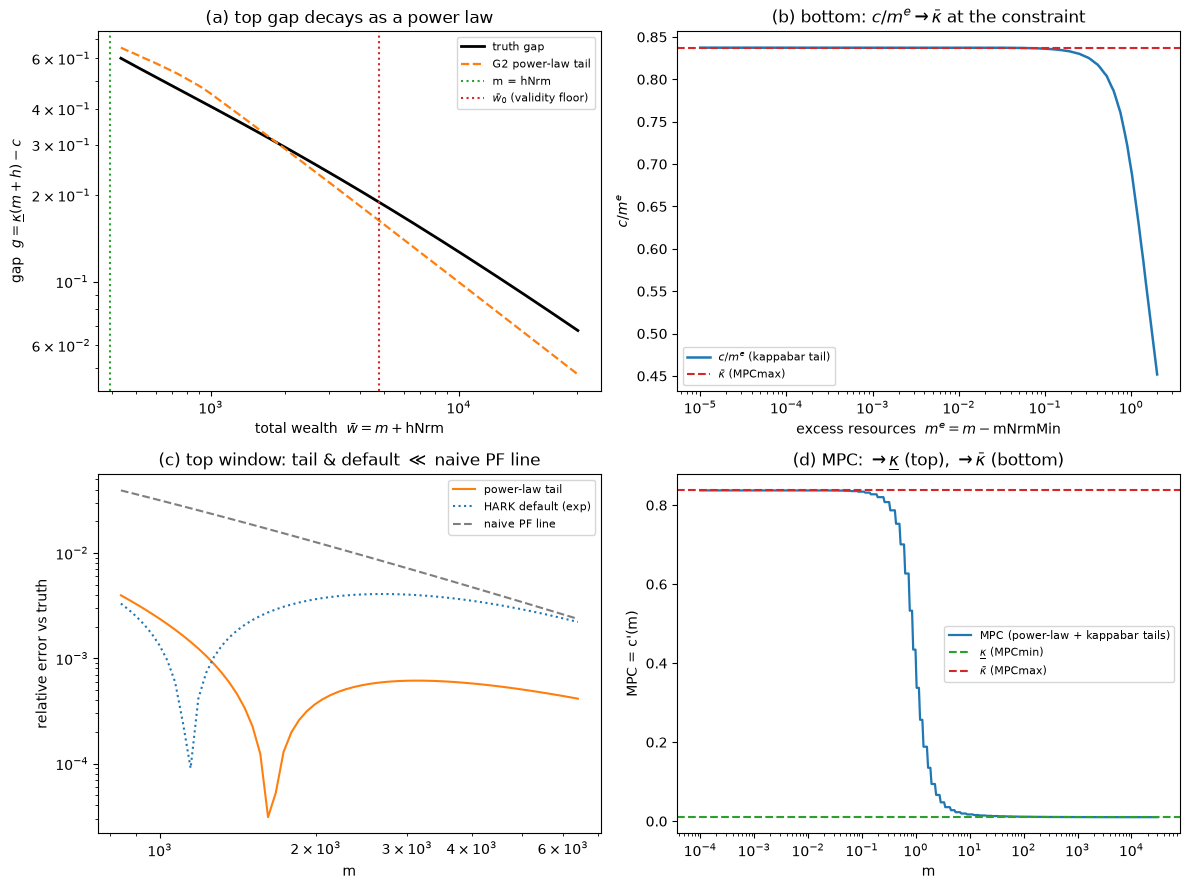

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) TOP gap g(wbar) log-log: truth, G2 knots, G2 tail, m=h and wbar0 verticals
ax = axes[0, 0]
wgrid = log_grid(1.2 * hB, 3.0e4, 400)
gap_truth = th.kappa * (wgrid + h) - np.asarray(truth.cFunc(wgrid), float)
gap_g2 = th.kappa * (wgrid + h) - np.asarray(sols["G2"]["tails"].cFunc(wgrid), float)
ax.loglog(wgrid + h, gap_truth, "k-", lw=2, label="truth gap")
ax.loglog(wgrid + h, gap_g2, "C1--", lw=1.6, label="G2 power-law tail")
ax.axvline(2 * h, color="C2", ls=":", label="m = hNrm")
ax.axvline(vt.wbar0, color="C3", ls=":", label=r"$\bar{w}_0$ (validity floor)")
ax.set_xlabel(r"total wealth  $\bar{w} = m + \mathrm{hNrm}$")
ax.set_ylabel(r"gap  $g = \underline{\kappa}(m+h) - c$")
ax.set_title("(a) top gap decays as a power law")
ax.legend(fontsize=8)

# (b) BOTTOM c/me -> kappa_bar
ax = axes[0, 1]
me = log_grid(1e-5, 2.0, 200)
c_bot = np.asarray(sols["G2"]["tails"].cFunc(me), float)
ax.semilogx(me, c_bot / me, "C0-", lw=1.8, label=r"$c/m^e$ (kappabar tail)")
ax.axhline(kap_bar, color="C3", ls="--", label=r"$\bar{\kappa}$ (MPCmax)")
ax.set_xlabel(r"excess resources  $m^e = m - \mathrm{mNrmMin}$")
ax.set_ylabel(r"$c / m^e$")
ax.set_title(r"(b) bottom: $c/m^e \to \bar{\kappa}$ at the constraint")
ax.legend(fontsize=8)

# (c) relative error above the G2 top knot: tails vs default vs PF line
ax = axes[1, 0]
ptop = fid["G2"]["ptop"]; ct = np.asarray(truth.cFunc(ptop), float)
ax.loglog(ptop, np.abs(np.asarray(sols["G2"]["tails"].cFunc(ptop), float) - ct) / ct,
          "C1-", label="power-law tail")
ax.loglog(ptop, np.abs(np.asarray(sols["G2"]["rails"].cFunc(ptop), float) - ct) / ct,
          "C0:", label="HARK default (exp)")
ax.loglog(ptop, np.abs(th.kappa * (ptop + h) - ct) / ct, "C7--", label="naive PF line")
ax.set_xlabel("m"); ax.set_ylabel("relative error vs truth")
ax.set_title("(c) top window: tail & default $\\ll$ naive PF line")
ax.legend(fontsize=8)

# (d) MPC across the range: -> MPCmin at top, -> kappa_bar at bottom
ax = axes[1, 1]
mm = log_grid(1e-4, 3.0e4, 400)
mpc = np.asarray(sols["G2"]["tails"].cFunc.derivative(mm), float)
ax.semilogx(mm, mpc, "C0-", lw=1.6, label="MPC (power-law + kappabar tails)")
ax.axhline(th.kappa, color="C2", ls="--", label=r"$\underline{\kappa}$ (MPCmin)")
ax.axhline(kap_bar, color="C3", ls="--", label=r"$\bar{\kappa}$ (MPCmax)")
ax.set_xlabel("m"); ax.set_ylabel("MPC = c'(m)")
ax.set_title(r"(d) MPC: $\to\underline{\kappa}$ (top), $\to\bar{\kappa}$ (bottom)")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## §4  The binding-constraint gate

The `kappabar` bottom tail attaches whenever the **natural** constraint is the
binding one — `BoroCnstArt is None` **or** `BoroCnstNat >= BoroCnstArt` — and is
refused only when an **artificial** constraint *strictly* binds (its constraint end
is an MPC-1 kink, so Theorem CE's $\text{MPC}\to\bar{\kappa}$ mechanism does not
operate there). With this calibration `BoroCnstNat = 0`.

In [7]:
for label, boro in [("no artificial constraint", None),
                    ("slack artificial (-0.5 < 0)", -0.5),
                    ("binding artificial (0.2 > 0)", 0.2)]:
    with warnings.catch_warnings(record=True) as wrec:
        warnings.simplefilter("always")
        s = solve(log_grid(1e-4, 1e3, 120), tol=1e-8,
                  BoroCnstArt=boro, decay_extrap_form_lower="kappabar")
    built = isinstance(s.cFunc, KappaBarTailInterp)
    note = "tail BUILT" if built else "refused (kept default secant)"
    print(f"BoroCnstArt={str(boro):>5} | mNrmMin={s.mNrmMin:6.3f} | {note:35} | {label}")


BoroCnstArt= None | mNrmMin= 0.000 | tail BUILT                          | no artificial constraint


BoroCnstArt= -0.5 | mNrmMin= 0.000 | tail BUILT                          | slack artificial (-0.5 < 0)
BoroCnstArt=  0.2 | mNrmMin= 0.200 | refused (kept default secant)       | binding artificial (0.2 > 0)


## §5  Two-roles coda

Because each backward step's assembled `cFunc` is what the *next* step's Euler
expectation evaluates, the tails act in **both** roles at once — inside the
solution recursion and on the returned policy. The in-solve vs eval-only factor
measured in §3 (large at the constraint end) is the quantitative statement of the
takeaway: **the tail must live inside the solver loop**, not be bolted on after.

In [8]:
g2 = sols["G2"]
print("In-solve vs post-hoc (eval-only) attachment of the SAME tail laws (G2):")
print(f"  bottom window: in-solve {fid['G2']['ebt']:.2e}  "
      f"post-hoc {ev_bot:.2e}  ->  in-solve is {ev_bot/fid['G2']['ebt']:.0f}x better")
print(f"  top window   : in-solve {fid['G2']['et']:.2e}  "
      f"post-hoc {ev_top:.2e}  (comparable at a good top anchor)")
print("\nTakeaway: the constraint-end tail belongs INSIDE the solver loop.")


In-solve vs post-hoc (eval-only) attachment of the SAME tail laws (G2):
  bottom window: in-solve 3.83e-08  post-hoc 8.49e-07  ->  in-solve is 22x better
  top window   : in-solve 3.96e-03  post-hoc 3.33e-03  (comparable at a good top anchor)

Takeaway: the constraint-end tail belongs INSIDE the solver loop.


### Summary

* Two opt-in, theorem-pinned tails; defaults `None` leave HARK byte-for-byte
  unchanged.
* **Bottom** (`kappabar`): the strong win — orders of magnitude better than the
  default secant near the constraint, and best attached in-solve.
* **Top** (`powerlaw`): the *principled* decay shape; numerically close to HARK's
  existing exp-decay at a sensible ($m \gtrsim h$) grid top, and clearly better at
  a pre-asymptotic anchor. Both beat the naive PF line.
* HARK ships the diagnostics to size the grid (`powerlaw_tail_diagnostic`,
  `aXtraMax_from_tail_tol`, `powerlaw_validity_threshold`) so you can check the
  handoff error *without* a truth solve.
